# Dog, Cat & Panda Image Classifier

**AMV10 Visual Analytics — Group 14**

This notebook trains a ResNet-50 classifier on the Dog/Cat/Panda dataset
and exports all artefacts needed by the VA dashboard:
- `export.pkl` — fastai learner for LIME explanations
- `va_export/predictions.csv` — predictions for all images
- Model weights for retraining

Dataset: [Animal Image Dataset (Dog, Cat, Panda)](https://www.kaggle.com/datasets/ashishsaxena2209/animal-image-datasetdog-cat-and-panda)

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

Failed to read module file 'C:\Users\20211233\AppData\Local\Programs\Python\Python311\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\.venv-1\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\20211233\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1178, in _find_and_load

In [2]:
from fastai import *
from fastai.vision import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from pathlib import Path
from PIL import Image as PILImage


In [3]:
def seed_everything(seed):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)
print('cudnn enabled:', torch.backends.cudnn.enabled)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

cudnn enabled: True
CUDA available: False


## 1. Data Loading

The dataset has 3 folders: `dogs/`, `cats/`, `panda/`, each containing ~1000 images.
We build a DataFrame with image paths and labels (0=Cat, 1=Dog, 2=Panda).

In [5]:
# Locate the dataset root folder robustly
# Expected structure:
# DCP/
#   cats/
#   dogs/
#   panda/

def find_data_dir(dirname='DCP'):
    candidates = [
        Path.cwd() / dirname,
        Path.cwd().parent / dirname,
        Path(r'c:/Users/20211233/Documents/GitHub/VA_DR_Dashboard') / dirname,
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not find '{dirname}'. Checked: " + ', '.join(str(p) for p in candidates)
    )

DATA_DIR = find_data_dir('DCP')

CLASS_MAP = {'cats': 0, 'dogs': 1, 'panda': 2}
CLASS_NAMES = {0: 'Cat', 1: 'Dog', 2: 'Panda'}
IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

print('Current working directory:', Path.cwd())
print('Using dataset directory   :', DATA_DIR)

rows = []
for folder, label in CLASS_MAP.items():
    folder_path = DATA_DIR / folder

    if not folder_path.is_dir():
        print(f'WARNING: {folder_path} not found')
        continue

    image_files = sorted([
        p for p in folder_path.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])

    print(f'{folder}: {len(image_files)} images found')

    for img_path in image_files:
        rows.append({
            'image_id': img_path.stem,
            'path': str(img_path.resolve()),
            'label': label,
            'class_name': CLASS_NAMES[label],
        })

if not rows:
    raise ValueError(
        'No image files were found. Check DATA_DIR and make sure DCP/cats, DCP/dogs, and DCP/panda contain images.'
    )

df = pd.DataFrame(rows)

print(f'Total images: {len(df)}')
print('Columns:', df.columns.tolist())
print('Class distribution:')
print(df['class_name'].value_counts())
display(df.head())


Current working directory: c:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\DCP
Using dataset directory   : C:\Users\20211233\Documents\GitHub\VA_DR_Dashboard\DCP
cats: 1000 images found
dogs: 1000 images found
panda: 1000 images found
Total images: 3000
Columns: ['image_id', 'path', 'label', 'class_name']
Class distribution:
class_name
Cat      1000
Dog      1000
Panda    1000
Name: count, dtype: int64


,image_id,path,label,class_name
0,cats_00001,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,Cat
1,cats_00002,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,Cat
2,cats_00003,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,Cat
3,cats_00004,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,Cat
4,cats_00005,C:\Users\20211233\Documents\GitHub\VA_DR_Dashb...,0,Cat


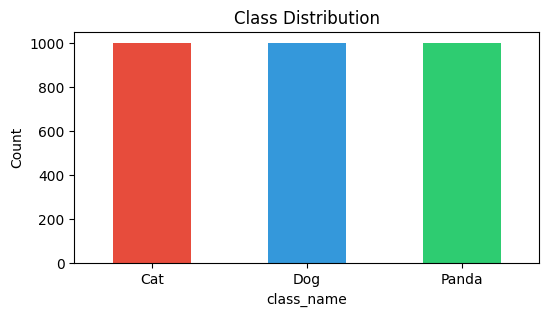

In [6]:
if df.empty:
    print('No data loaded, so class distribution cannot be plotted yet.')
else:
    ax = df['class_name'].value_counts().plot.bar(figsize=(6, 3), color=['#e74c3c', '#3498db', '#2ecc71'])
    plt.title('Class Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()


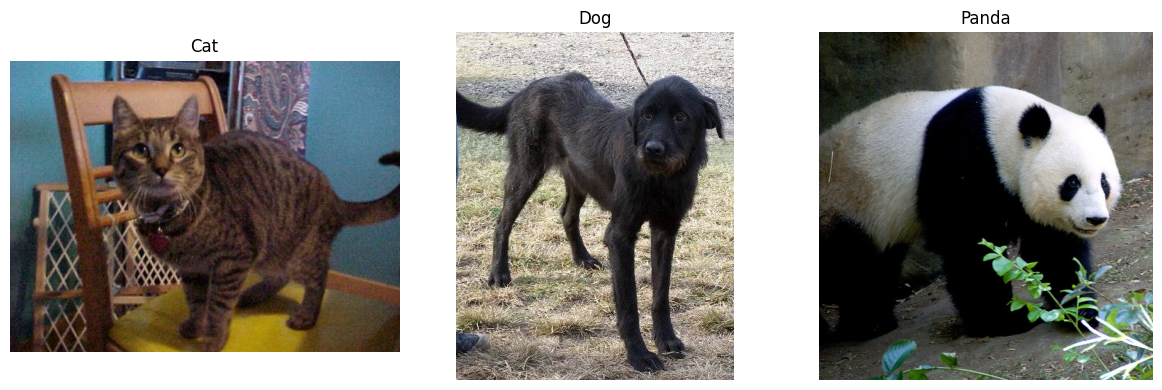

In [7]:
# Show one sample image per class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cls in enumerate(['cats', 'dogs', 'panda']):
    class_rows = df[df['class_name'] == CLASS_NAMES[CLASS_MAP[cls]]]
    axes[i].axis('off')

    if class_rows.empty:
        axes[i].set_title(f'No image for {cls}')
        continue

    sample = class_rows.iloc[0]
    img = PILImage.open(sample['path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(sample['class_name'])

plt.tight_layout()
plt.show()


## 2. Create fastai DataBunch

We use fastai's ImageDataBunch with standard augmentations.
This is a **classification** task (not regression like DR grading).

In [8]:
bs = 64
sz = 224

tfms = get_transforms(do_flip=True, flip_vert=False, max_rotate=15,
                       max_warp=0, max_zoom=1.1, max_lighting=0.2)

data = (ImageList.from_df(df=df, path='./', cols='path')
        .split_by_rand_pct(0.2, seed=SEED)
        .label_from_df(cols='class_name')
        .transform(tfms, size=sz)
        .databunch(bs=bs)
        .normalize(imagenet_stats))

print(f'Train: {len(data.train_ds)}, Valid: {len(data.valid_ds)}')
print(f'Classes: {data.classes}')

OSError: [Errno 22] Invalid argument: np.str_('.\\C:\\Users\\20211233\\Documents\\GitHub\\VA_DR_Dashboard\\DCP\\cats\\cats_00002.jpg')

In [ ]:
data.show_batch(rows=3, figsize=(9, 6))

NameError: name 'data' is not defined

## 3. Train ResNet-50

Transfer learning from ImageNet. This is a standard 3-class classification
with cross-entropy loss (fastai default for categorical labels).

In [ ]:
learn = cnn_learner(data, base_arch=models.resnet50, metrics=[accuracy])

In [ ]:
learn.lr_find()
learn.recorder.plot(suggestion=True)

In [ ]:
learn.fit_one_cycle(4, max_lr=1e-2)

In [ ]:
learn.recorder.plot_losses()
learn.recorder.plot_metrics()

In [ ]:
learn.unfreeze()
learn.lr_find()
learn.recorder.plot(suggestion=True)

In [ ]:
learn.fit_one_cycle(6, max_lr=slice(1e-6, 1e-3))

In [ ]:
learn.recorder.plot_losses()
learn.recorder.plot_metrics()

In [ ]:
# Save model
learn.export()
learn.save('stage-2')
print('Saved export.pkl and models/stage-2.pth')

## 4. Evaluate

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8, 8), dpi=60)

In [ ]:
interp.plot_top_losses(9, figsize=(12, 12))

## 5. Export artefacts for VA dashboard

We need:
1. `predictions.csv` — image_id, true_class, pred_class, confidence, class_confidences
2. The model is used live by the dashboard (no separate embeddings file needed — hidden layers extracted on the fly)

In [ ]:
EXPORT_DIR = os.path.join('.', 'va_export')
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── Get predictions for ALL images (train + valid) ──────────────────
# We need to create a test set from ALL images to get predictions
all_image_list = ImageList.from_df(df=df, path='./', cols='path')

# Add as test set and predict
learn.data.add_test(all_image_list)
preds, _ = learn.get_preds(ds_type=DatasetType.Test)

# preds is (N, 3) softmax probabilities
probs = preds.numpy()
pred_classes = probs.argmax(axis=1)

# Map fastai class indices to our labels
# fastai sorts class names alphabetically: Cat=0, Dog=1, Panda=2
fastai_classes = data.classes  # e.g. ['Cat', 'Dog', 'Panda']
print(f'fastai class order: {fastai_classes}')

# Build class name to our label mapping
name_to_label = {v: k for k, v in CLASS_NAMES.items()}
fastai_idx_to_label = [name_to_label[c] for c in fastai_classes]
print(f'fastai index → our label: {fastai_idx_to_label}')

In [ ]:
# Build predictions DataFrame
predictions = []
for i in range(len(df)):
    row = df.iloc[i]
    prob_vec = probs[i]  # [Cat_prob, Dog_prob, Panda_prob] in fastai order
    pred_idx = pred_classes[i]
    pred_label = fastai_idx_to_label[pred_idx]
    
    # Reorder probs to our label order (0=Cat, 1=Dog, 2=Panda)
    ordered_probs = [float(prob_vec[fastai_classes.index(CLASS_NAMES[j])]) for j in range(3)]
    
    predictions.append({
        'image_id': row['image_id'],
        'true_class': int(row['label']),
        'pred_class': int(pred_label),
        'confidence': round(float(prob_vec.max()), 4),
        'class_confidences': json.dumps([round(p, 4) for p in ordered_probs]),
    })

pred_df = pd.DataFrame(predictions)
print(f'Predictions shape: {pred_df.shape}')
print(f'Accuracy: {(pred_df["true_class"] == pred_df["pred_class"]).mean():.1%}')
pred_df.head()

In [ ]:
# Save predictions
pred_df.to_csv(os.path.join(EXPORT_DIR, 'predictions.csv'), index=False)
print(f'Saved: {EXPORT_DIR}/predictions.csv ({len(pred_df)} rows)')

# Save class mapping
class_info = {
    'class_names': CLASS_NAMES,
    'fastai_classes': fastai_classes,
    'fastai_idx_to_label': fastai_idx_to_label,
    'num_classes': 3,
}
with open(os.path.join(EXPORT_DIR, 'class_info.json'), 'w') as f:
    json.dump(class_info, f, indent=2)
print(f'Saved: {EXPORT_DIR}/class_info.json')

In [ ]:
print('\n=== Export Summary ===')
print(f'export.pkl          : model for LIME + dashboard')
print(f'va_export/predictions.csv : {len(pred_df)} predictions')
print(f'va_export/class_info.json : class mapping')
print(f'\nAccuracy: {(pred_df["true_class"] == pred_df["pred_class"]).mean():.1%}')
print(f'\nTo run the dashboard:')
print(f'  1. Copy export.pkl to the dashboard folder')
print(f'  2. Copy va_export/ to the dashboard folder')
print(f'  3. Make sure the images folder is accessible')
print(f'  4. python app_DCP.py')